#LAB 2: EDA + DATA PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
import sys
from packaging import version
import sklearn

assert sys.version_info >= (3, 7) #This line checks that the version of Python being used is 3.7 or higher
assert version.parse(sklearn.__version__) >= version.parse("1.0.1") #This line checks that the version of Scikit-learn being used is 1.0.1 or higher.

# TASK 1: Load and Explore the Dataset

In [3]:
from pathlib import Path  # Importing the Path class from the pathlib module to handle file system paths
import pandas as pd  # Importing pandas as pd for data manipulation and analysis
import tarfile  # Importing the tarfile module to work with tar archive files
import urllib.request  # Importing urllib.request to handle URL operations

def load_housing_data():
    # Define the path to the tarball file
    tarball_path = Path("datasets/housing.tgz")

    # Check if the tarball file already exists
    if not tarball_path.is_file():
        # Create the datasets directory if it does not exist
        Path("datasets").mkdir(parents=True, exist_ok=True)

        # URL where the dataset is located
        url = "https://github.com/ageron/data/raw/main/housing.tgz"

        # Download the tarball file from the URL to the specified path
        urllib.request.urlretrieve(url, tarball_path)

        # Open the tarball file
        with tarfile.open(tarball_path) as housing_tarball:
            # Extract all files from the tarball to the datasets directory
            housing_tarball.extractall(path="datasets")


    ##### Here is our main activity ######
    # Load the housing.csv file into a pandas DataFrame and return it
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# Call the function to load the housing data into a DataFrame
housing = load_housing_data()

In [4]:
# Display the first five rows of the housing DataFrame to get an initial overview of the data
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Get a concise summary of the housing DataFrame, including the data types, non-null counts, and memory usage
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
# Display the count of unique values in the "ocean_proximity" column to understand the distribution of this categorical feature
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# Generate descriptive statistics for the numerical columns in the housing DataFrame to summarize the central tendency, dispersion, and shape of the dataset's distribution
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


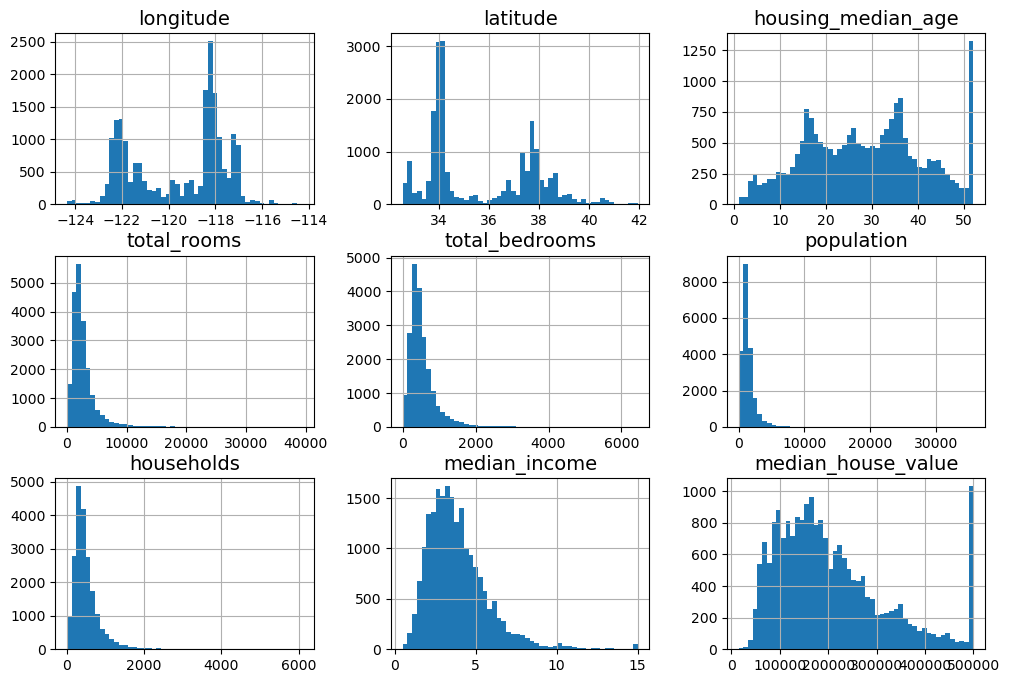

In [8]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Generate histograms for each numerical column in the housing DataFrame
housing.hist(bins=50, figsize=(12, 8)) # Plot histograms with 50 bins and a figure size of 12x8 inches
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

# TASK 2: CREATE TEST SET

In [9]:
import numpy as np  # Importing the numpy library, which provides support for large, multi-dimensional arrays and matrices

def shuffle_and_split_data(data, test_ratio):
    # Shuffle the indices of the data randomly
    shuffled_indices = np.random.permutation(len(data)) #generates a randomly shuffled array of indices from 0 to the length of the dataset minus one. This ensures that the data is randomly shuffled before splitting.

    # Calculate the size of the test set based on the test_ratio
    test_set_size = int(len(data) * test_ratio)

    # Select the first part of the shuffled indices as the test set indices
    test_indices = shuffled_indices[:test_set_size]

    # Select the remaining part of the shuffled indices as the training set indices
    train_indices = shuffled_indices[test_set_size:]

    # Return the training and test sets based on the indices
    return data.iloc[train_indices], data.iloc[test_indices]



In [10]:
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = shuffle_and_split_data(housing, 0.2)

# Output the length of the training set to verify the split
len(train_set)

16512

In [11]:
# Output the length of the test set to verify the split
len(test_set)

4128

In [12]:
test_set["total_bedrooms"].isnull().sum()

np.int64(41)

In [20]:
np.random.seed(42)

In [21]:
from sklearn.model_selection import train_test_split
# Split the housing data into a training set and a test set with a 20% test size
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [23]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

**Create five income categories from median income atribute**

In [24]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

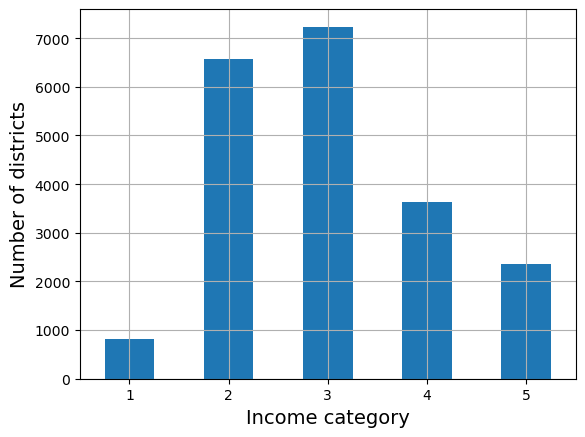

In [25]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
#save_fig("housing_income_cat_bar_plot")  # extra code
plt.show()

**Stratify sampling based on income category and compare the stratified sampling with purely random sampling**

In [26]:
from sklearn.model_selection import StratifiedShuffleSplit  # Importing StratifiedShuffleSplit for creating stratified train-test splits

# Initialize the StratifiedShuffleSplit object with 10 splits, 20% test size, and a random state for reproducibility
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Initialize an empty list to store the stratified splits
strat_splits = []

# Iterate through the splits generated by the StratifiedShuffleSplit object
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    # Create the training set using the train indices
    strat_train_set_n = housing.iloc[train_index]

    # Create the test set using the test indices
    strat_test_set_n = housing.iloc[test_index]

    # Append the training and test sets as a pair to the list of stratified splits
    strat_splits.append([strat_train_set_n, strat_test_set_n])


In [27]:
# Extract the first pair of stratified training and test sets
strat_train_set, strat_test_set = strat_splits[0]

Since stratified sampling is fairly common, there is a shorter way to get a single split. You can simply use following much shorter code to get a single stratified split:

In [28]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

Following line of code calculates the proportion of each income category within the strat_test_set DataFrame.

In [29]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In the following code, we compare the distribution of income categories in the entire dataset, a stratified test set, and a randomly split test set. It helps to evaluate how well the stratified sampling preserves the original distribution of the income categories compared to a random split.

In [30]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


Following code removes the **income_cat** column from both the strat_train_set and strat_test_set DataFrames. This code iterates over the strat_train_set and strat_test_set DataFrames, removing the income_cat column from each. This clean-up step is essential to ensure that the temporary column used for stratified sampling does not affect further analysis or modeling.

In [31]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Task 3: Discover and Visualize the Data to Gain Insights

Start by creating a copy of training dataset, **strat_train_set**.

In [32]:
#creates a copy of the strat_train_set DataFrame
housing = strat_train_set.copy()

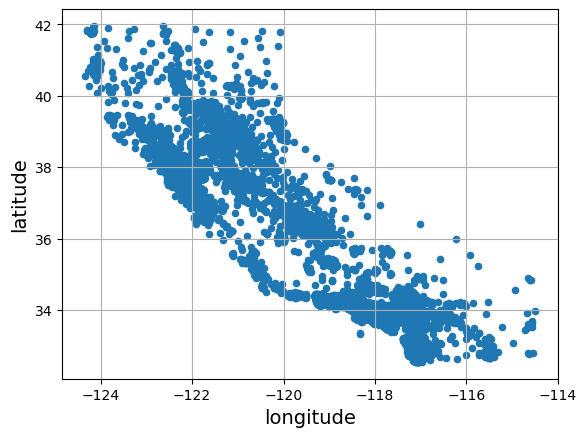

In [33]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
#save_fig("bad_visualization_plot")  # extra code
plt.show()

Following code generates a scatter plot of the housing DataFrame, plotting longitude on the x-axis and latitude on the y-axis, with added transparency to the points.

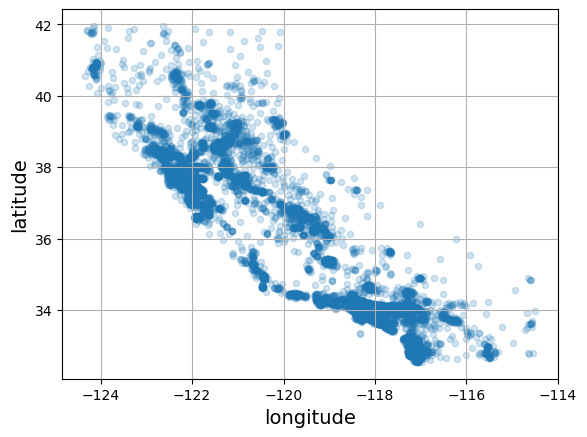

In [34]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
#save_fig("better_visualization_plot")  # extra code
plt.show()

We can even geenrate more complex scatter plot of the housing DataFrame, with additional visual features to represent population size and median house value.

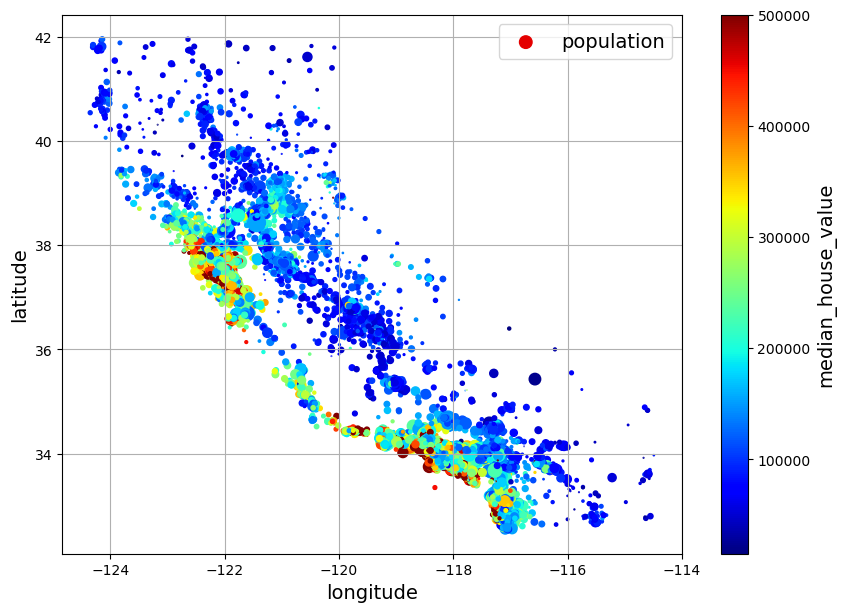

In [112]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
#save_fig("housing_prices_scatterplot")  # extra code
plt.show()

**Looking for Correlations**

In [35]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

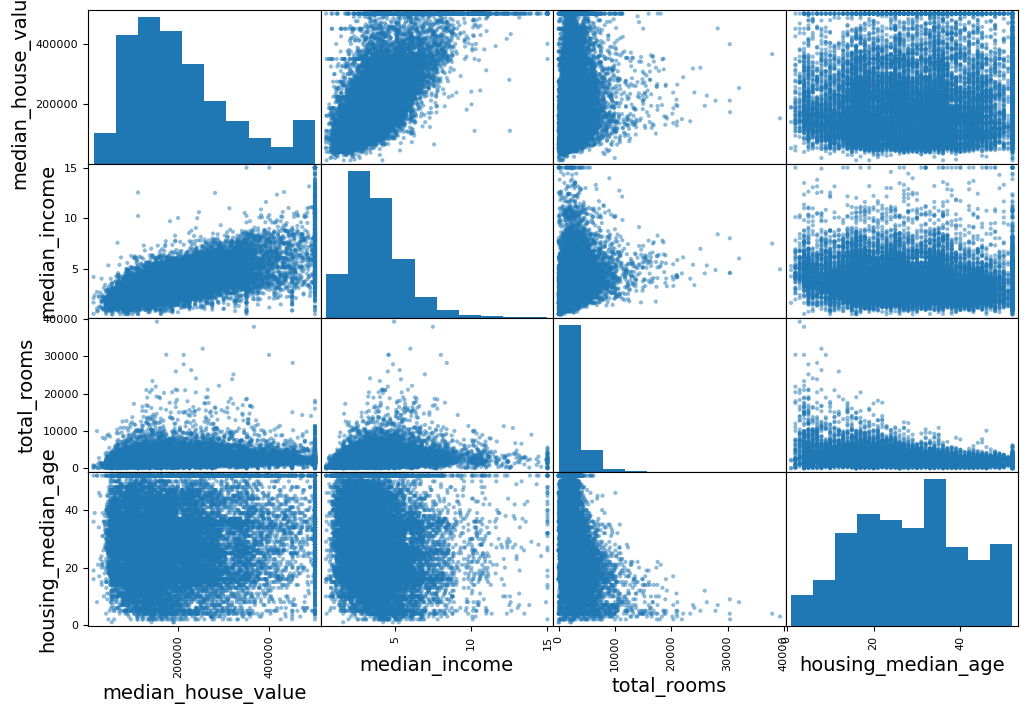

In [114]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

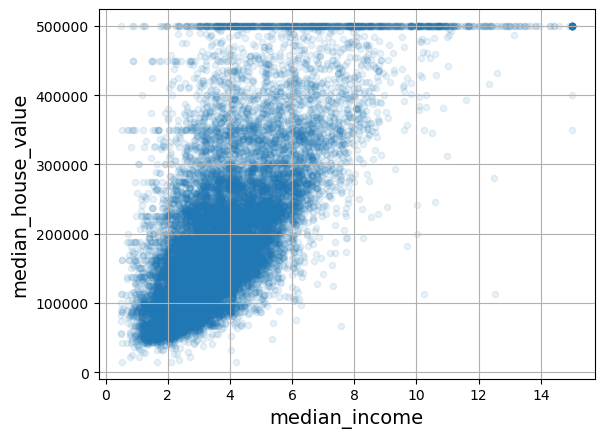

In [115]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
#save_fig("income_vs_house_value_scatterplot")  # extra code
plt.show()

**Experimenting with Attribute Combinations**

In [36]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

This line computes the pairwise correlation matrix for all numerical features in the housing DataFrame.

In [117]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

# TASK 4: DATA CLEANING

Prepare the Data for Machine Learning Algorithms

In [38]:
# Create a new DataFrame, housing, which contains all the features (input data) except the target variable, median_house_value
strat_housing = strat_train_set.drop("median_house_value", axis=1)
# Create a new Series, housing_labels, which contains the target variable, median_house_value
strat_housing_labels = strat_train_set["median_house_value"].copy()
#The housing_labels Series now contains the target variable values, which will be used for training the machine learning model.

In [39]:
housing.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
 10  rooms_per_house     16512 non-null  float64
 11  bedrooms_ratio      16344 non-null  float64
 12  people_per_house    16512 non-null  float64
dtypes: float64(12), str(1)
memory usage: 1.8 MB


**Taking care of numerical missing attributes**

In [40]:
null_rows_idx = strat_housing.isnull().any(axis=1)
strat_housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


**Option 1**

* Following code demonstrates option 1 for handling missing data.
* This option removes all the rows from the data where the total_bedrooms column has missing values (NaN).

In [121]:
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option1 = strat_housing.copy()

# Remove rows where the total_bedrooms column has missing values (Option 1)
strat_housing_option1.dropna(subset=["total_bedrooms"], inplace=True)

# Attempt to display the first five rows that still contain missing values (if any)
strat_housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


**Option 2**

* Following code demonstrates option 2 for handling missing data.
* This option removes the entire column from the data that contains missing values (NaN), total_bedrooms.

In [122]:
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option2 = strat_housing.copy()

# Remove the total_bedrooms column entirely (Option 2)
strat_housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

# Attempt to display the first five rows that still contain missing values (if any)
strat_housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


**Option 3**

* Following code demonstrates another option (option 3) for handling missing data: filling missing values in a specific column (total_bedrooms) with the median value of that column.
* The median is a robust measure of central tendency that can be used to fill missing values without being affected by outliers

In [123]:
# Create a copy of the housing DataFrame to experiment with data cleaning options
strat_housing_option3 = strat_housing.copy()

# Calculate the median value of the total_bedrooms column in the housing DataFrame
median = strat_housing["total_bedrooms"].median()

# Fill the missing values in the total_bedrooms column of housing_option3 with the median value calculated in the previous step.
strat_housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3

strat_housing_option3.loc[null_rows_idx].head()

/var/folders/h3/lvc96bhs559bzb5k1v075w480000gn/T/ipykernel_54092/632447514.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  strat_housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


**Option 4: SimpleImputer class**
* The SimpleImputer class provides basic strategies for imputing missing values. Missing values can be imputed with a provided constant value, or using the statistics (mean, median or most frequent) of each column in which the missing values are located.
* Using SimpleImputer ensures a consistent and efficient way to handle missing data, especially when working with large datasets or when the same strategy needs to be applied across multiple columns or datasets.


In [47]:
# Import the SimpleImputer class from the sklearn.impute module
from sklearn.impute import SimpleImputer

# Create an imputer instance with the strategy to fill missing values with the median value
imputer = SimpleImputer(strategy="median")

Separating out the numerical attributes to use the `"median"` strategy (as it cannot be calculated on text attributes like `ocean_proximity`):
* This code creates a new DataFrame, housing_num, which contains only the numerical columns from the original housing DataFrame.

In [48]:
# Select only the numerical columns from the housing DataFrame and assign them to housing_num
strat_housing_num = strat_housing.select_dtypes(include=[np.number])

In [49]:
# Fit the SimpleImputer instance to the numerical columns of the housing DataFrame
# This calculates the median values for each numerical column and stores them in the imputer
imputer.fit(strat_housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [50]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [51]:
strat_housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

**Transforming the training set using Imputer:**

In [52]:
# Transform the numerical columns of the housing DataFrame using the fitted SimpleImputer
# This fills in missing values with the median values calculated during the fitting step
X = imputer.transform(strat_housing_num)

In [130]:
# Retrieve the names of the features that the SimpleImputer was fitted on
# This provides a list of column names that were included in the imputation process
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

The primary purpose of the following code is to convert the imputed data back into a DataFrame format, retaining the original structure (column names and row indices).

In [53]:
# Convert the NumPy array resulting from the imputation back into a DataFrame
# Restore the original column names and row indices from the housing_num DataFrame
strat_housing_tr = pd.DataFrame(X, columns=strat_housing_num.columns,
                          index=strat_housing_num.index)

In [56]:
strat_housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [57]:
imputer.strategy

'median'

Now let's drop some outliers:

In [58]:
from sklearn.ensemble import IsolationForest

# Create an instance of the IsolationForest with a fixed random state for reproducibility
isolation_forest = IsolationForest(random_state=42)

# Fit the IsolationForest model to the data and predict outliers
outlier_pred = isolation_forest.fit_predict(X)

In [59]:
# The fit_predict method returns an array where 1 indicates an inlier and -1 indicates an outlier
outlier_pred

array([-1,  1,  1, ...,  1,  1,  1], shape=(16512,))

**Handling Text and Categorical Attributes**

In [60]:
# Extract the 'ocean_proximity' column from the housing DataFrame and assign it to housing_cat
strat_housing_cat = strat_housing[["ocean_proximity"]]

# Display the first 8 rows of the housing_cat DataFrame to preview the 'ocean_proximity' data
strat_housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


The purpose of following code is to encode the categorical ocean_proximity feature into numerical values using the OrdinalEncoder from Scikit-learn.

In [61]:
# Import the OrdinalEncoder from sklearn.preprocessing
from sklearn.preprocessing import OrdinalEncoder

# Create an instance of the OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Fit the OrdinalEncoder to the housing_cat data and transform it into numerical values
strat_housing_cat_encoded = ordinal_encoder.fit_transform(strat_housing_cat)

In [138]:
strat_housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [62]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

# TASK 5: FEATURE SCALING

**Min-Max Scaling**

In [63]:
# Import the MinMaxScaler from sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler

# Create an instance of the MinMaxScaler with the feature range set to [-1, 1]
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit the MinMaxScaler to the housing_num data and transform it
# This scales each numerical feature to the range [-1, 1]
strat_housing_num_min_max_scaled = min_max_scaler.fit_transform(strat_housing_num)

**Standard Scaling**

In [64]:
# Import the StandardScaler from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
std_scaler = StandardScaler()

# Fit the StandardScaler to the housing_num data and transform it
# This standardizes each numerical feature by removing the mean and scaling to unit variance
strat_housing_num_std_scaled = std_scaler.fit_transform(strat_housing_num)

**Faeture Scalling for Heavy Tail Distribution**

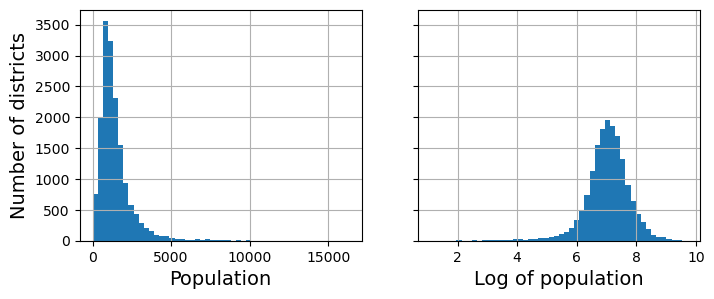

In [65]:
# extra code – this cell generates Figure 2–17 in the Book
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
strat_housing["population"].hist(ax=axs[0], bins=50)
strat_housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
#save_fig("long_tail_plot")
plt.show()

**Feature Scaling for Multimodal Distributions**

In [66]:
# Import the rbf_kernel function from sklearn.metrics.pairwise
from sklearn.metrics.pairwise import rbf_kernel

# Compute the RBF kernel similarity between the housing_median_age feature and the age 35
# The gamma parameter controls the influence of a single training example
age_simil_35 = rbf_kernel(strat_housing[["housing_median_age"]], [[35]], gamma=0.1)

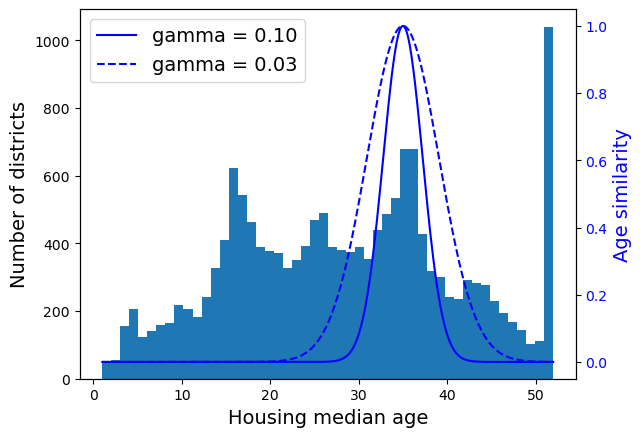

In [67]:
# extra code – this cell generates Figure 2–18

ages = np.linspace(strat_housing["housing_median_age"].min(),
                   strat_housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(strat_housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
#save_fig("age_similarity_plot")
plt.show()

## Task 6: Custom Transformers and Transformation Pipelines

**Custom Transformers**

In [68]:
# Import the FunctionTransformer from sklearn.preprocessing
from sklearn.preprocessing import FunctionTransformer

# Create a FunctionTransformer for the logarithmic transformation
# np.log applies the natural logarithm, and np.exp is the inverse function
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

# Apply the logarithmic transformation to the population feature
log_pop = log_transformer.transform(strat_housing[["population"]])

**RBF Kernel Transformation**

In [69]:
# Create a FunctionTransformer for the RBF kernel transformation
# rbf_kernel computes the RBF kernel similarity, with Y=[[35.]] and gamma=0.1 as additional arguments
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))

# Apply the RBF kernel transformation to the housing_median_age feature
age_simil_35 = rbf_transformer.transform(strat_housing[["housing_median_age"]])

In [70]:
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]], shape=(16512, 1))

**Similarity between the Geographical Coordinates and Specific Location**

In [71]:
# Define the coordinates of San Francisco (latitude, longitude)
sf_coords = 37.7749, -122.41

# Create a FunctionTransformer for the RBF kernel transformation
# rbf_kernel computes the RBF kernel similarity, with San Francisco's coordinates and gamma=0.1
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))


# Apply the RBF kernel transformation to the latitude and longitude features
# This computes the similarity of each housing unit's coordinates to San Francisco's coordinates
sf_simil = sf_transformer.transform(strat_housing[["latitude", "longitude"]])

In [72]:
sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]], shape=(16512, 1))

**In the following code, we create a custom transformer using Scikit-learn's FunctionTransformer **

In [73]:
# Create a FunctionTransformer to calculate the ratio of the first column to the second column
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])

# Apply the ratio transformer to a sample 2D NumPy array
# This computes the ratio for each row: first column value divided by second column value
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

**Custom Transformer: StandardScalerClone**

In [74]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

# Define a custom transformer class for standard scaling
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # Initialize with an optional with_mean parameter
        self.with_mean = with_mean

    def fit(self, X, y=None): # Fit method to calculate mean and scale # y is required even though we don't use it
        X = check_array(X) # Validate input array # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0) # Calculate mean of each feature
        self.scale_ = X.std(axis=0) # Calculate standard deviation of each feature
        self.n_features_in_ = X.shape[1]  # Store the number of features # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X): # Transform method to standardize the data
        check_is_fitted(self)  # Ensure the transformer has been fitted
        X = check_array(X) # Validate input array
        assert self.n_features_in_ == X.shape[1] # Ensure the number of features matches
        if self.with_mean:
            X = X - self.mean_  # Center the data by subtracting the mean if with_mean is True
        return X / self.scale_ # Scale the data by dividing by the standard deviation

**Custom Transformer: ClusterSimilarity**

In [75]:
# Import the KMeans class from sklearn.cluster
from sklearn.cluster import KMeans

# Define a custom transformer class for cluster similarity using K-means and RBF kernel
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        # Initialize with parameters for the number of clusters, RBF kernel gamma, and random state
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # Create and fit a K-means model with the specified number of clusters and random state
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        # Transform the data by computing the RBF kernel similarity to the cluster centers
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        # Generate feature names for the transformed data
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [76]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(strat_housing[["latitude", "longitude"]],
                                           sample_weight=strat_housing_labels)

In [77]:
similarities[:3].round(2)

array([[0.08, 0.  , 0.6 , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.14],
       [0.  , 0.99, 0.  , 0.04, 0.  , 0.  , 0.11, 0.  , 0.63, 0.  ],
       [0.44, 0.  , 0.3 , 0.  , 0.  , 0.7 , 0.  , 0.01, 0.  , 0.29]])

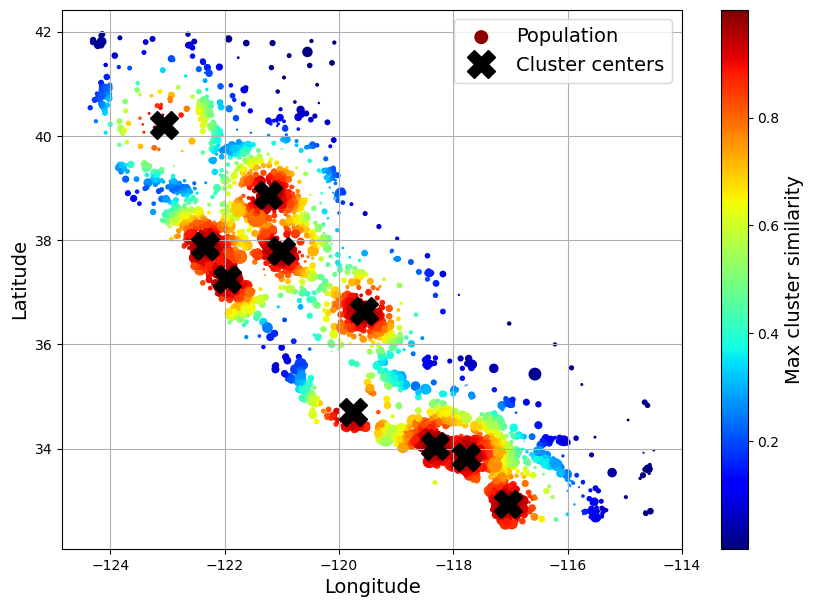

In [78]:
# extra code – this cell generates Figure 2–19

strat_housing_renamed = strat_housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
strat_housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

strat_housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=strat_housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
#save_fig("district_cluster_plot")
plt.show()

**Transformation Pipelines**

In [79]:
from sklearn.pipeline import Pipeline

# Create a pipeline for preprocessing numerical attributes
# The pipeline includes two steps: imputation and standardization
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")), # Step 1: Impute missing values with the median
    ("standardize", StandardScaler()), # Step 2: Standardize features to have mean=0 and variance=1
])

In [80]:
from sklearn.pipeline import make_pipeline

# Create a pipeline for preprocessing numerical attributes using make_pipeline
# The pipeline also includes two steps: imputation and standardization
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [81]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [82]:
strat_housing_num_prepared = num_pipeline.fit_transform(strat_housing_num)
strat_housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [83]:
df_housing_num_prepared = pd.DataFrame(
    strat_housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=strat_housing_num.index)

In [84]:
df_housing_num_prepared.head(2)  # extra code to check the feature names

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


In [162]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [163]:
num_pipeline[1]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [164]:
num_pipeline[:-1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has 

In [85]:
num_pipeline.named_steps["simpleimputer"]

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [166]:
num_pipeline.set_params(simpleimputer__strategy="median")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

**Column Transformer: handling multiple columns in the dataset**

In [86]:
# Import the ColumnTransformer class from sklearn.compose
from sklearn.compose import ColumnTransformer

# Define the numerical attributes
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]

# Define the categorical attributes
cat_attribs = ["ocean_proximity"]

# Create a pipeline for preprocessing categorical attributes
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # Step 1: Impute missing values with the most frequent value
    OneHotEncoder(handle_unknown="ignore"))  # Step 2: One-hot encode categorical features and ignore unknown categories

# Combine numerical and categorical pipelines using ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs), # Apply the numerical pipeline to numerical attributes
    ("cat", cat_pipeline, cat_attribs),  # Apply the categorical pipeline to categorical attributes
])

In [87]:
from sklearn.compose import make_column_selector, make_column_transformer

In [88]:
strat_housing_prepared = preprocessing.fit_transform(strat_housing)

In [89]:
# extra code – shows that we can get a DataFrame out if we want
strat_housing_prepared_fr = pd.DataFrame(
    strat_housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=strat_housing.index)
strat_housing_prepared_fr.head(2)

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
